# Dunning–Kruger in LLMs — Analysis & Plotting

This notebook consolidates the analysis used to test whether large language models show a **Dunning–Kruger–style** pattern: do *less capable* models (smaller, or base rather than instruction-tuned) report **high confidence despite low accuracy**, and does calibration improve with scale?

It is the cleaned, de-duplicated version of the exploratory plotting notebooks — one coherent pass from raw per-model results to the headline figures, with the redundant variants removed.

**Inputs.** One CSV per model (a "mega" CSV), produced by the evaluation scripts in `Python HPC versions/` and optionally merged in **Section 1**. Each row is one question with the model's answer, correctness (`is_correct`), and the six confidence signals (MSP, Entropy, Margin, P(1), P(True), Verbal).

**The analysis, in order:**
1. *(optional)* Build per-model mega CSVs from per-category files.
2. **Configuration** — folders, metrics, colours, families.
3. **Load & clean** — drop non-compliant rows; optionally intersect a family to a shared question set.
4. **Aggregate** per model → accuracy + mean confidence (0–100).
5. **Calibration metrics** — ECE, Brier, AUROC, Pearson *r* per model per metric.
6. **Figure A — Confidence vs. accuracy across scale (Base vs. Instruct).** The central DK test.
7. **Figure B — Over-confidence gap** (confidence − accuracy).
8. **Figure C — Reliability diagrams** (calibration curves).
9. **Figure D — Calibration-metric heatmaps** (ECE / Brier / AUROC / *r*).

> A Dunning–Kruger reading: a confidence line sitting **above** the dashed accuracy line for the smaller/weaker models, an over-confidence gap that **shrinks with scale**, and discrimination (AUROC) that **improves with scale** even where absolute calibration (ECE) does not.


## 1. *(Optional)* Build per-model "mega" CSVs

The evaluation scripts write **one CSV per subject/category** (e.g. `mmlu_abstract_algebra_<model>_instruct_all.csv`). This helper merges all category files for a model into a single per-model CSV, adding `Category` and `Model` columns.

Run this once per model to produce the `mega_*.csv` files the rest of the notebook expects, then skip it on later runs. Set `file_prefix="mmlupro_"` for the MMLU-Pro outputs.


In [1]:
import os
import glob
import pandas as pd


def merge_categories(folder_path, categories_list, model_name, file_prefix="mmlu_"):
    """Merge per-category result CSVs for one model into a single DataFrame.

    Looks for files matching '<file_prefix><category>_*.csv' inside folder_path,
    tags each with its Category and the given model_name, and concatenates them.
    Use file_prefix='mmlupro_' for MMLU-Pro outputs.
    """
    all_dfs = []
    print(f"{'Category':<28} | {'Status':<10} | Rows")
    print("-" * 52)

    for cat in categories_list:
        files = glob.glob(os.path.join(folder_path, f"{file_prefix}{cat}_*.csv"))
        if files:
            df = pd.read_csv(files[0])
            df["Category"] = cat
            df["Model"] = model_name
            all_dfs.append(df)
            print(f"{cat:<28} | Success    | {len(df)}")
        else:
            print(f"{cat:<28} | MISSING    | file not found")

    if not all_dfs:
        print("No data merged."); return None

    mega = pd.concat(all_dfs, ignore_index=True)
    # Normalise a couple of legacy column names if present.
    if "correct_mmlu" in mega.columns:
        mega = mega.rename(columns={"correct_mmlu": "is_correct"})
    if "greedy_matches_msp" in mega.columns:
        mega = mega.drop(columns=["greedy_matches_msp"])
    print("-" * 52)
    print(f"TOTAL ROWS: {len(mega)}")
    return mega


# ── Example (edit folder / categories / model, then uncomment to run) ─────────
# MMLU_CATEGORIES = [
#     "abstract_algebra", "college_mathematics", "elementary_mathematics",
#     "high_school_mathematics", "college_biology", "high_school_biology",
#     "professional_medicine", "high_school_psychology", "college_physics",
#     "conceptual_physics", "high_school_physics", "college_computer_science",
#     "high_school_computer_science", "professional_psychology", "econometrics",
#     "sociology", "public_relations", "security_studies", "high_school_geography",
#     "philosophy", "prehistory", "high_school_world_history",
#     "high_school_european_history", "moral_disputes", "logical_fallacies",
#     "jurisprudence", "international_law", "world_religions",
# ]
# mega = merge_categories("gemma_instruct_raw", MMLU_CATEGORIES,
#                         model_name="Gemma-2-2B-Instruct", file_prefix="mmlu_")
# if mega is not None:
#     mega.to_csv("mega_2B_gemma_instruct.csv", index=False)


## 2. Configuration

Point the four folders at your per-model `mega_*.csv` files — one folder per condition (base/instruct × MMLU/MMLU-Pro). `CONF_METRICS` maps each confidence signal to its column name(s) and a scale factor (`100` turns a 0–1 metric into 0–100; verbal confidence is already 0–100, so `1`). Margin auto-detects the MMLU column (`Margin_renorm_ABCD`) or the MMLU-Pro column (`Margin_renorm_options`).


In [3]:
import os
import re
import glob
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D
from sklearn.metrics import brier_score_loss, roc_auc_score

try:
    from IPython.display import display
except ImportError:                       # plain-Python fallback
    display = print

warnings.filterwarnings("ignore")

# ── DATA FOLDERS (edit these four paths) ─────────────────────────────────────
# Each folder holds the per-model mega CSVs for one condition.
FOLDER_INSTRUCT_MMLU    = "all_csv_files_instruct (mmlu)"
FOLDER_BASE_MMLU        = "all_csv_files_base (mmlu)"
FOLDER_INSTRUCT_MMLUPRO = "all_csv_files_instruct (mmlu-pro)"
FOLDER_BASE_MMLUPRO     = "all_csv_files_base (mmlu-pro)"

SAVE_FIGS = True      # write each figure to disk as a dissertation-ready PNG
FIG_DPI   = 500

# If a model loses MORE than this fraction of rows to NA / non-compliant cleaning,
# every model in that family is reduced to the INTERSECTION of surviving questions,
# so all sizes are scored on exactly the same items.
INTERSECTION_THRESHOLD = 0.10            # 10%
QUESTION_KEY_CANDIDATES = ["__orig_row__"]

# Confidence metric -> (candidate column names, scale_to_0_100).
CONF_METRICS = {
    "Letter_MSP_confidence": (["Letter_MSP_confidence"],                       100),
    "Entropy_as_confidence": (["Entropy_as_confidence"],                       100),
    "Margin_renorm":         (["Margin_renorm_ABCD", "Margin_renorm_options"], 100),
    "p_true_probability":    (["p_true_probability"],                          100),
    "p1_probability":        (["p1_probability"],                              100),
    "verbal_integer_found":  (["verbal_integer_found"],                          1),
}

CONF_LABELS = {
    "Letter_MSP_confidence": "MSP",
    "Entropy_as_confidence": "Entropy",
    "Margin_renorm":         "Margin",
    "p_true_probability":    "P(True)",
    "p1_probability":        "P(1)",
    "verbal_integer_found":  "Verbal",
}

# Family detection (from filename) + colours. 'lama' is the spelling some files use.
FAMILY_CANON  = {"gemma": "gemma", "qwen": "qwen", "lama": "llama", "llama": "llama"}
FAMILY_COLORS = {"gemma": "#1b9e77", "qwen": "#7570b3", "llama": "#d95f02"}


def is_math_category(cat):
    """Harder-benchmark flag (math-only); kept for the math_only option in compute_scores."""
    c = str(cat).lower()
    return ("math" in c) or ("algebra" in c)


## 3. Load & clean (per folder)

`load_clean` reads every CSV in a folder, parses each model's **size** and **family** from the filename, and drops rows where the model produced no valid answer letter (`letter_llm_outputted_detected` blank). If any model in a family loses more than `INTERSECTION_THRESHOLD` of its rows, all models in that family are reduced to their shared (intersection) question set, so different sizes are compared on identical items. A row-exclusion report is printed for transparency.


In [4]:
def parse_model_name(path):
    """Return (size_in_billions, family) parsed from e.g. 'mega_27B_gemma_instruct.csv'."""
    base = os.path.basename(path).lower()
    family = None
    for key, canon in FAMILY_CANON.items():
        if re.search(rf"_{key}_", base):
            family = canon
            break
    m = re.search(r"mega_(\d+(?:\.\d+)?)\s*b?_", base)   # number after 'mega_'
    size = float(m.group(1)) if m else np.nan
    return size, family


def first_present(df, candidates):
    """Return the first candidate column name that exists in df, else None."""
    for c in candidates:
        if c in df.columns:
            return c
    return None


def get_question_keys(df):
    for c in QUESTION_KEY_CANDIDATES:
        if c in df.columns:
            return df[c].astype(str), c
    return df["__orig_row__"].astype(str), "__orig_row__"


def load_clean(folder, tag):
    """Load + clean every per-model CSV in `folder`. Returns a list of
    (size, family, cleaned_df, filename) tuples, ordered smallest -> largest."""
    files = sorted(glob.glob(os.path.join(folder, "*.csv")))
    if not files:
        raise FileNotFoundError(f"No CSV files in {folder!r}. Check the folder paths in Section 2.")

    print("=" * 78)
    print(f"DATA LOADING & ROW-EXCLUSION REPORT  [{tag}]   folder={folder!r}")
    print("=" * 78)

    # 1. read + per-model NA / non-compliant cleaning
    models = []
    for f in files:
        size, family = parse_model_name(f)
        df = pd.read_csv(f)
        df["__orig_row__"] = np.arange(len(df))
        total = len(df)

        col = "letter_llm_outputted_detected"
        blank = df[col].isna() | (df[col].astype(str).str.strip() == "")
        kept = df[~blank].copy()

        excluded  = int(blank.sum())
        drop_frac = (excluded / total) if total else 0.0
        n_cat = kept["Category"].nunique() if "Category" in kept.columns else 0
        print(f"  {str(family):>5s} {size:>4g}B | {total:>5d} rows | "
              f"{excluded:>4d} excluded | {len(kept):>5d} kept "
              f"({100*len(kept)/total:5.1f}%) | NA-drop {100*drop_frac:4.1f}% | {n_cat} cats")
        models.append(dict(size=size, family=family, df=kept, fn=os.path.basename(f),
                           total=total, excluded=excluded, drop_frac=drop_frac))

    # 2. per-family intersection if any model dropped > threshold
    for fam in sorted({m["family"] for m in models if m["family"] is not None}):
        fam_models = [m for m in models if m["family"] == fam]
        if len(fam_models) < 2:
            continue
        worst = max(m["drop_frac"] for m in fam_models)
        if worst <= INTERSECTION_THRESHOLD:
            continue

        print("-" * 78)
        print(f"  INTERSECTION TRIGGERED for family '{fam}' [{tag}] "
              f"(worst NA-drop = {100*worst:.1f}% > {100*INTERSECTION_THRESHOLD:.0f}%).")

        key_col   = get_question_keys(fam_models[0]["df"])[1]
        pre_counts = {m["total"] for m in fam_models}
        if key_col == "__orig_row__" and len(pre_counts) > 1:
            print(f"    WARNING: '{fam}' models do not share the same pre-clean row count "
                  f"{sorted(pre_counts)}; positional alignment may be unreliable.")

        key_sets = [set(get_question_keys(m["df"])[0]) for m in fam_models]
        common   = set.intersection(*key_sets)
        print(f"    question key: {key_col}")
        print(f"    common questions kept across all {len(fam_models)} '{fam}' models: {len(common)}")

        for m in fam_models:
            keys, kc = get_question_keys(m["df"])
            before   = len(m["df"])
            m["df"]  = m["df"][keys.isin(common)].drop_duplicates(subset=[kc]).copy()
            after    = len(m["df"])
            print(f"      {m['family']:>5s} {m['size']:>4g}B | {before:>5d} -> {after:>5d} rows "
                  f"(removed {before - after} to match the family)")

    # 3. order smallest -> largest
    loaded = [(m["size"], m["family"], m["df"], m["fn"]) for m in models]
    loaded.sort(key=lambda t: t[0])
    print("=" * 78); print()
    return loaded


## 4. Aggregate per model (0–100 scale)

`compute_scores` collapses each model's rows to one row: its **accuracy** and its **mean** of each confidence metric, all on a 0–100 scale. The result is a tidy table — one row per model, ordered by size — that drives the trend and over-confidence figures. We build it for all four conditions.


In [5]:
def compute_scores(loaded, math_only=False):
    """Per-model accuracy + mean of each confidence metric, scaled to 0-100."""
    rows = []
    for size, family, df, fn in loaded:
        d = df[df["Category"].map(is_math_category)] if math_only else df
        rec = {
            "size": size,
            "family": family,
            "label": f"{family} {size:g}B",
            "n": len(d),
            "accuracy": d["is_correct"].astype(int).mean() * 100 if len(d) else np.nan,
        }
        for key, (cands, scale) in CONF_METRICS.items():
            col = first_present(d, cands)
            rec[key] = (pd.to_numeric(d[col], errors="coerce").mean() * scale
                        if (col and len(d)) else np.nan)
        rows.append(rec)
    return pd.DataFrame(rows)


# ── Load + score all four conditions ─────────────────────────────────────────
loaded_instruct_mmlu    = load_clean(FOLDER_INSTRUCT_MMLU,    "INSTRUCT-MMLU")
loaded_base_mmlu        = load_clean(FOLDER_BASE_MMLU,        "BASE-MMLU")
loaded_instruct_mmlupro = load_clean(FOLDER_INSTRUCT_MMLUPRO, "INSTRUCT-MMLU-PRO")
loaded_base_mmlupro     = load_clean(FOLDER_BASE_MMLUPRO,     "BASE-MMLU-PRO")

scores_instruct_mmlu    = compute_scores(loaded_instruct_mmlu)
scores_base_mmlu        = compute_scores(loaded_base_mmlu)
scores_instruct_mmlupro = compute_scores(loaded_instruct_mmlupro)
scores_base_mmlupro     = compute_scores(loaded_base_mmlupro)

print("INSTRUCT (MMLU) — per-model accuracy & mean confidence:")
display(scores_instruct_mmlu.round(2))


DATA LOADING & ROW-EXCLUSION REPORT  [INSTRUCT-MMLU]   folder='all_csv_files_instruct (mmlu)'
   qwen  1.5B |  6233 rows |    0 excluded |  6233 kept (100.0%) | NA-drop  0.0% | 28 cats
   qwen   14B |  6233 rows |    7 excluded |  6226 kept ( 99.9%) | NA-drop  0.1% | 28 cats
  llama    1B |  6233 rows |    1 excluded |  6232 kept (100.0%) | NA-drop  0.0% | 28 cats
  gemma   27B |  6233 rows |    2 excluded |  6231 kept (100.0%) | NA-drop  0.0% | 28 cats
  gemma    2B |  6233 rows |   17 excluded |  6216 kept ( 99.7%) | NA-drop  0.3% | 28 cats
   qwen   32B |  6233 rows |    0 excluded |  6233 kept (100.0%) | NA-drop  0.0% | 28 cats
   qwen    3B |  6233 rows |    0 excluded |  6233 kept (100.0%) | NA-drop  0.0% | 28 cats
  llama   70B |  6233 rows |    0 excluded |  6233 kept (100.0%) | NA-drop  0.0% | 28 cats
   qwen   72B |  6233 rows |    1 excluded |  6232 kept (100.0%) | NA-drop  0.0% | 28 cats
   qwen    7B |  6233 rows |    0 excluded |  6233 kept (100.0%) | NA-drop  0.0% | 28 c

,size,family,label,n,accuracy,Letter_MSP_confidence,Entropy_as_confidence,Margin_renorm,p_true_probability,p1_probability,verbal_integer_found
0,1.0,llama,llama 1B,6232,46.07,58.79,30.32,37.81,55.24,37.08,12.73
1,1.5,qwen,qwen 1.5B,6233,63.61,87.33,76.53,77.85,40.12,89.53,93.91
2,2.0,gemma,gemma 2B,6216,40.11,95.52,91.86,91.53,79.67,99.99,86.84
3,3.0,qwen,qwen 3B,6233,69.04,96.35,93.45,92.97,38.45,69.96,95.07
4,7.0,qwen,qwen 7B,6233,75.16,93.73,88.59,88.35,64.07,88.12,87.74
5,8.0,llama,llama 8B,6233,67.19,80.13,64.57,67.69,50.78,70.32,79.72
6,9.0,gemma,gemma 9B,6229,75.73,94.54,88.47,90.30,82.40,95.68,89.63
7,14.0,qwen,qwen 14B,6226,80.23,97.76,96.17,95.64,70.46,88.29,77.72
8,27.0,gemma,gemma 27B,6231,77.84,94.15,87.79,89.55,95.28,93.65,86.96
9,32.0,qwen,qwen 32B,6233,84.07,97.03,94.85,94.31,74.10,83.56,91.55


## 5. Calibration metrics — ECE, Brier, AUROC, Pearson *r*

Aggregate means hide *how* confidence relates to correctness. These four row-level metrics, computed per model per confidence signal, capture it:

- **ECE** (Expected Calibration Error, 10 equal-width bins) — gap between confidence and accuracy; **lower is better**.
- **Brier score** — mean squared error of confidence vs. correctness; **lower is better**.
- **AUROC** — how well confidence *discriminates* correct from incorrect answers; **higher is better**.
- **Pearson *r*** — linear correlation between row-level confidence and correctness.

The DK-relevant signal is the **dissociation**: discrimination (AUROC) can rise with scale even where absolute calibration (ECE) does not.


In [6]:
def _conf_and_correct(df, key):
    """Return (confidence in [0,1], correctness 0/1) for one metric, NaNs dropped & aligned."""
    cands, scale = CONF_METRICS[key]
    col = first_present(df, cands)
    if col is None or len(df) == 0:
        return None, None
    sub = pd.DataFrame({
        "c": (pd.to_numeric(df[col], errors="coerce") * scale) / 100.0,
        "y": pd.to_numeric(df["is_correct"], errors="coerce"),
    }).dropna()
    if sub.empty:
        return None, None
    conf = sub["c"].clip(0, 1).reset_index(drop=True)
    correct = sub["y"].astype(int).reset_index(drop=True)
    return conf, correct


def ece_score(conf_0_1, correct, n_bins=10):
    """Expected Calibration Error over `n_bins` equal-width bins on [0,1]."""
    conf_pct = conf_0_1 * 100
    bins = np.linspace(0, 100, n_bins + 1)
    idx = np.digitize(conf_pct, bins) - 1
    idx = idx.clip(0, n_bins - 1)            # keep 100.0 in the last bin
    ece, n = 0.0, len(conf_0_1)
    for b in range(n_bins):
        mask = (idx == b)
        if mask.any():
            ece += mask.sum() / n * abs(correct[mask].mean() - conf_0_1[mask].mean())
    return ece


def compute_calibration(loaded):
    """results[metric_key][model_label] = {ECE, Brier, AUROC, Corr}; plus ordered labels."""
    results = {k: {} for k in CONF_METRICS}
    labels = []
    for size, family, df, fn in loaded:
        label = f"{family} {size:g}B"
        labels.append(label)
        for key in CONF_METRICS:
            conf, correct = _conf_and_correct(df, key)
            if conf is None:
                results[key][label] = dict(ECE=np.nan, Brier=np.nan, AUROC=np.nan, Corr=np.nan)
                continue
            try:
                auroc = roc_auc_score(correct, conf)      # needs both classes present
            except ValueError:
                auroc = np.nan
            results[key][label] = dict(
                ECE=ece_score(conf, correct),
                Brier=brier_score_loss(correct, conf),
                AUROC=auroc,
                Corr=conf.corr(correct.astype(float)),
            )
    return results, labels


def print_calibration_table(results, labels, title):
    print("\n" + "=" * 78)
    print(title)
    print("=" * 78)
    print(f"{'METRIC':<10} {'MODEL':<14} {'ECE':>8} {'Brier':>9} {'AUROC':>8} {'Corr r':>9}")
    print("-" * 78)
    for key in CONF_METRICS:
        for j, lab in enumerate(labels):
            r = results[key][lab]
            prefix = CONF_LABELS[key] if j == 0 else ""
            print(f"{prefix:<10} {lab:<14} {r['ECE']:>8.3f} {r['Brier']:>9.4f} "
                  f"{r['AUROC']:>8.4f} {r['Corr']:>9.4f}")
        print("-" * 78)


cal_instruct_mmlu, labels_instruct_mmlu = compute_calibration(loaded_instruct_mmlu)
cal_base_mmlu,     labels_base_mmlu     = compute_calibration(loaded_base_mmlu)
cal_instruct_pro,  labels_instruct_pro  = compute_calibration(loaded_instruct_mmlupro)
cal_base_pro,      labels_base_pro      = compute_calibration(loaded_base_mmlupro)

print_calibration_table(cal_instruct_mmlu, labels_instruct_mmlu, "CALIBRATION METRICS — INSTRUCT (MMLU)")



CALIBRATION METRICS — INSTRUCT (MMLU)
METRIC     MODEL               ECE     Brier    AUROC    Corr r
------------------------------------------------------------------------------
MSP        llama 1B          0.127    0.2401   0.6809    0.3315
           qwen 1.5B         0.238    0.2578   0.7622    0.3594
           gemma 2B          0.554    0.5487   0.6044    0.0958
           qwen 3B           0.273    0.2755   0.7709    0.2492
           qwen 7B           0.186    0.1954   0.8179    0.3819
           llama 8B          0.129    0.1863   0.8088    0.4804
           gemma 9B          0.189    0.1961   0.8282    0.3685
           qwen 14B          0.175    0.1772   0.8409    0.2927
           gemma 27B         0.163    0.1718   0.8471    0.4200
           qwen 32B          0.130    0.1356   0.8504    0.3514
           llama 70B         0.067    0.1134   0.8598    0.5039
           qwen 72B          0.107    0.1164   0.8577    0.4112
--------------------------------------------------

## 6. Figure A — Confidence vs. accuracy across scale (Base vs. Instruct)

The headline figure. Each panel plots a confidence metric (coloured line) against the **dashed black accuracy line**, as model size increases left→right; marker shape encodes family (● LLaMA, ▲ Qwen, ■ Gemma). Rows group the six signals (Verbal · next-token distribution · P(1) · P(True)); the two columns are **Instruct vs. Base**.

This is the core Dunning–Kruger test: a confidence line riding **above** accuracy for the smaller models — and a gap that closes (or doesn't) with scale — is exactly the pattern in question. Comparing the Instruct and Base columns isolates the effect of instruction tuning.


In [7]:
# Row order: Verbal -> next-token distribution (MSP/Entropy/Margin) -> P(1) -> P(True)
GROUPS = [
    ("Verbal",
        ["verbal_integer_found"]),
    ("Next-token distribution\n(MSP \u00b7 Entropy \u00b7 Margin)",
        ["Letter_MSP_confidence", "Entropy_as_confidence", "Margin_renorm"]),
    ("P(1)",
        ["p1_probability"]),
    ("P(True)",
        ["p_true_probability"]),
]

SHORT = {"verbal_integer_found": "Verbal", "Letter_MSP_confidence": "MSP",
         "Entropy_as_confidence": "Entropy", "Margin_renorm": "Margin",
         "p1_probability": "P(1)", "p_true_probability": "P(True)"}

METRIC_COLORS = {"verbal_integer_found": "#6C8A2A", "Letter_MSP_confidence": "#62BBC2",
                 "Entropy_as_confidence": "#F5305B", "Margin_renorm": "#7633AA",
                 "p1_probability": "#FF9933", "p_true_probability": "#2C5FA8"}

FAM_MARKER  = {"llama": "o", "qwen": "^", "gemma": "s"}
FAM_GLYPH   = {"llama": "\u25CF", "qwen": "\u25B2", "gemma": "\u25A0"}
FAM_DISPLAY = {"llama": "LLaMA", "qwen": "Qwen", "gemma": "Gemma"}


def _line_skipnan(ax, x, y, **kw):
    """Plot a line that bridges NaN points so a missing model doesn't break the line."""
    y = np.asarray(y, dtype=float)
    m = ~np.isnan(y)
    ax.plot(np.asarray(x)[m], y[m], **kw)


def plot_dk_grouped(cols, suptitle, save_as=None):
    """cols: list of (column_title, scores_df). One column -> single-condition figure;
    two columns -> side-by-side comparison. Always 4 metric rows (GROUPS)."""
    nrows = len(GROUPS)
    ncols = len(cols)
    fig_w = 12 if ncols == 2 else 6.6
    fig, axes = plt.subplots(nrows, ncols, figsize=(fig_w, 2.7 * nrows + 1.2),
                             sharex="col", sharey=True, squeeze=False)

    for r, (glabel, keys) in enumerate(GROUPS):
        for c, (cond, s) in enumerate(cols):
            ax = axes[r, c]
            x = np.arange(len(s))
            fams = s["family"].values

            # dashed accuracy reference line in every panel
            _line_skipnan(ax, x, s["accuracy"], color="black", ls="--", lw=1.7,
                          marker="o", ms=4, mfc="white", zorder=6)

            for key in keys:
                y = np.asarray(s[key], dtype=float)
                col = METRIC_COLORS[key]
                _line_skipnan(ax, x, y, color=col, lw=1.8, alpha=0.9, zorder=3)
                for fam, mk in FAM_MARKER.items():
                    idx = np.where(fams == fam)[0]
                    if len(idx):
                        ax.scatter(x[idx], y[idx], marker=mk, s=58, c=col,
                                   edgecolor="black", linewidth=0.5, zorder=4)

            ax.grid(alpha=0.25, linestyle=":")
            ax.tick_params(labelsize=7)
            if r == 0:
                ax.set_title(cond, fontsize=13, fontweight="bold", pad=8)
            if c == 0:
                ax.set_ylabel("Score (%)", fontsize=7, labelpad=2)
                ax.text(-0.20 if ncols == 2 else -0.26, 0.5, glabel,
                        transform=ax.transAxes, rotation=90, ha="center", va="center",
                        fontsize=9.5, fontweight="bold", clip_on=False,
                        multialignment="center")
            if r == nrows - 1:
                ax.set_xticks(x)
                ax.set_xticklabels([f"{FAM_GLYPH.get(f, '')} {lab}"
                                    for f, lab in zip(s["family"], s["label"])],
                                   rotation=45, ha="right", fontsize=7)
                ax.set_xlabel("LLM model (family and size)", fontsize=9, labelpad=6)

    for ax in axes.flat:
        ax.set_ylim(0, 105)
        ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%g"))

    used = [k for _, ks in GROUPS for k in ks]
    metric_h = [Line2D([0], [0], color=METRIC_COLORS[k], lw=2.6, label=SHORT[k]) for k in used]
    fam_h = [Line2D([0], [0], marker=FAM_MARKER[f], ls="", mfc="0.5", mec="black",
                    ms=9, label=f"{FAM_DISPLAY[f]} ({FAM_GLYPH[f]})") for f in FAM_MARKER]
    extra = [Line2D([0], [0], color="black", ls="--", marker="o", mfc="white", label="Accuracy")]
    fig.legend(handles=metric_h + fam_h + extra, loc="lower center", ncol=5,
               frameon=False, fontsize=9, bbox_to_anchor=(0.5, -0.02))

    fig.suptitle(suptitle, fontsize=14, fontweight="bold", y=0.995)
    left = 0.12 if ncols == 2 else 0.20
    fig.tight_layout(rect=[left, 0.07, 1, 0.97])
    if SAVE_FIGS and save_as:
        fig.savefig(save_as, dpi=FIG_DPI, bbox_inches="tight",
                    facecolor="white", edgecolor="none")
        print("saved", save_as)
    plt.show()
    return fig


saved figA1_dk_grouped_mmlu.png


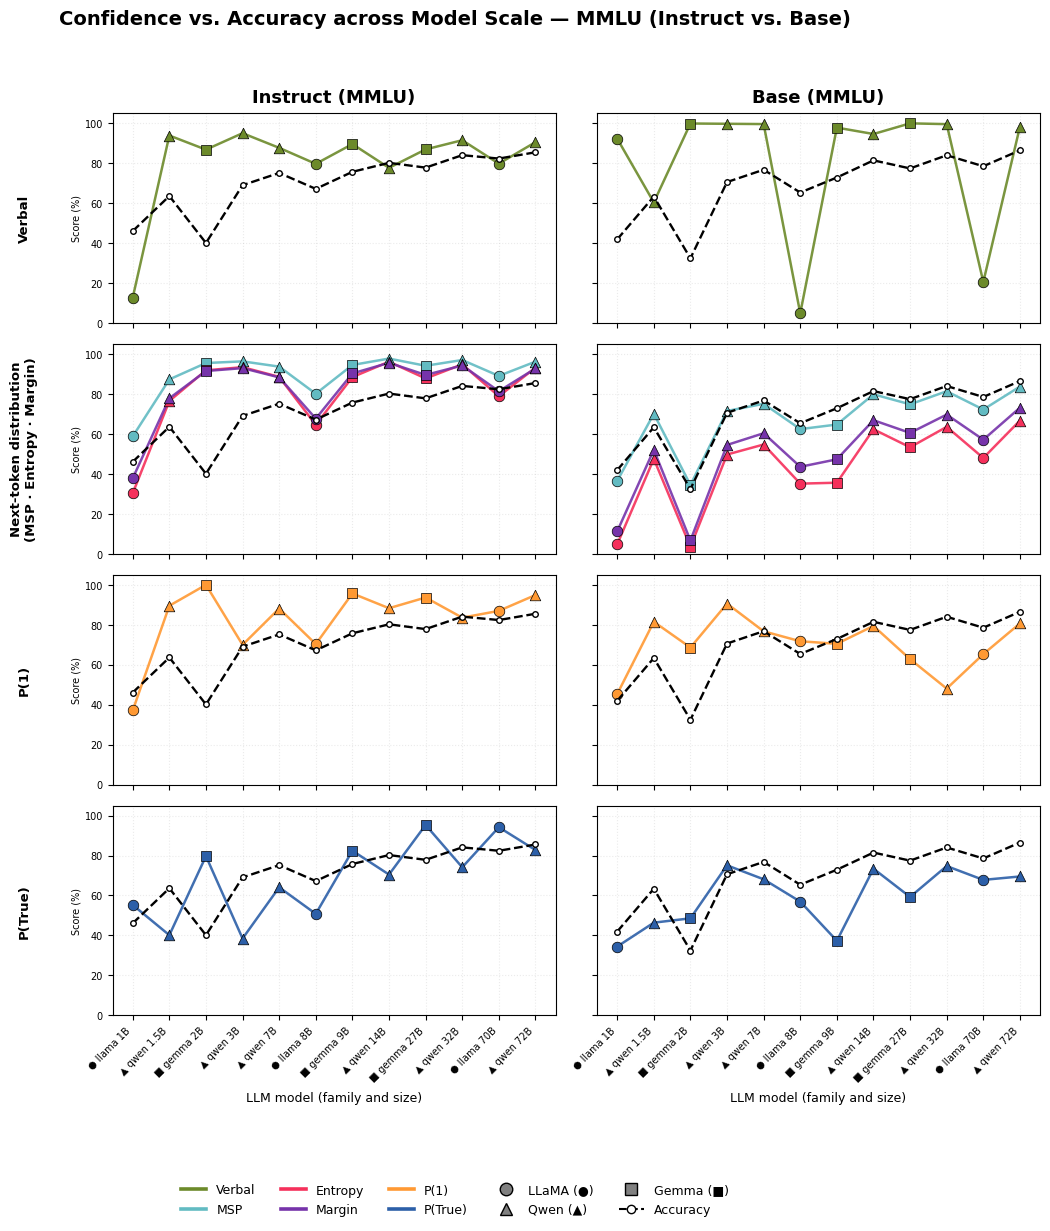

saved figA2_dk_grouped_mmlupro.png


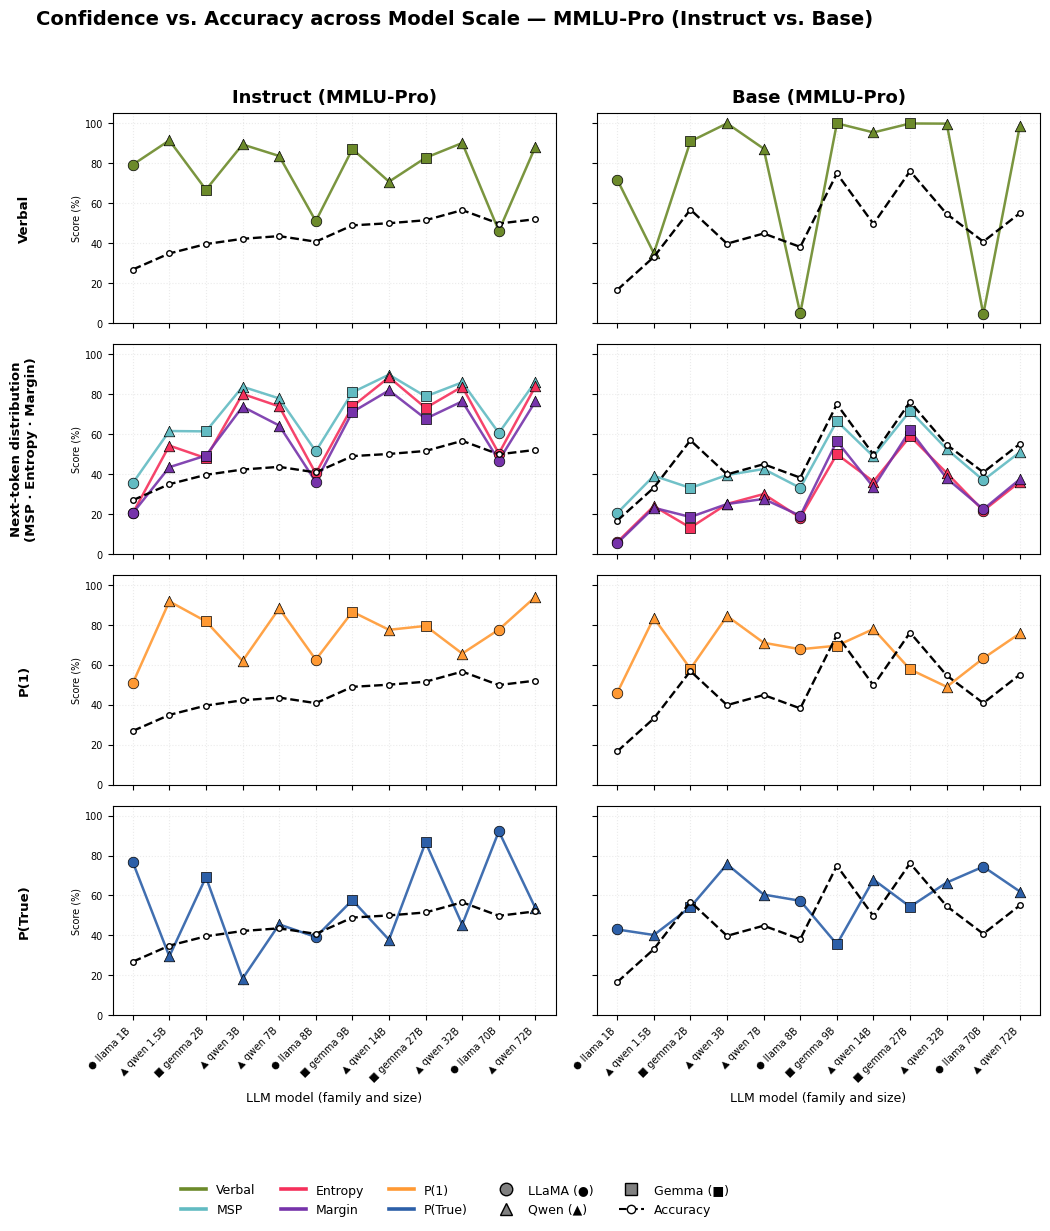

In [8]:
# Figure A1 — MMLU: Instruct vs. Base
plot_dk_grouped(
    [("Instruct (MMLU)", scores_instruct_mmlu),
     ("Base (MMLU)",     scores_base_mmlu)],
    "Confidence vs. Accuracy across Model Scale — MMLU (Instruct vs. Base)",
    save_as="figA1_dk_grouped_mmlu.png")

# Figure A2 — MMLU-Pro: Instruct vs. Base
plot_dk_grouped(
    [("Instruct (MMLU-Pro)", scores_instruct_mmlupro),
     ("Base (MMLU-Pro)",     scores_base_mmlupro)],
    "Confidence vs. Accuracy across Model Scale — MMLU-Pro (Instruct vs. Base)",
    save_as="figA2_dk_grouped_mmlupro.png");


## 7. Figure B — Over-confidence gap (confidence − accuracy)

The same information distilled to a single number per model per metric: **confidence minus accuracy**. Positive bars = **over-confident**, negative = under-confident, zero = perfectly calibrated. Reading left→right (small→large models) shows whether over-confidence **shrinks with scale** — the quantitative core of the Dunning–Kruger claim.


saved figB_overconfidence_instruct_mmlu.png


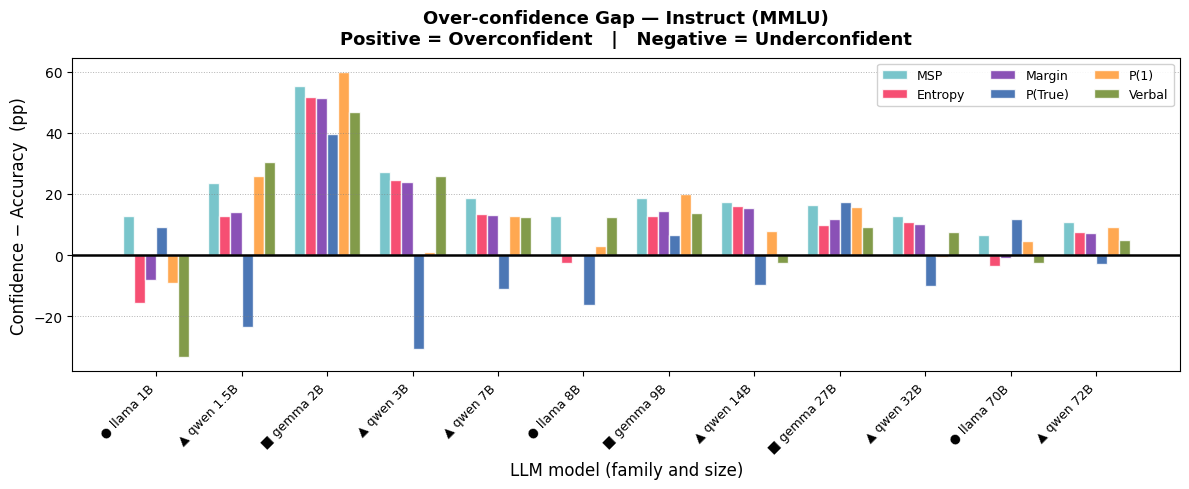

saved figB_overconfidence_base_mmlu.png


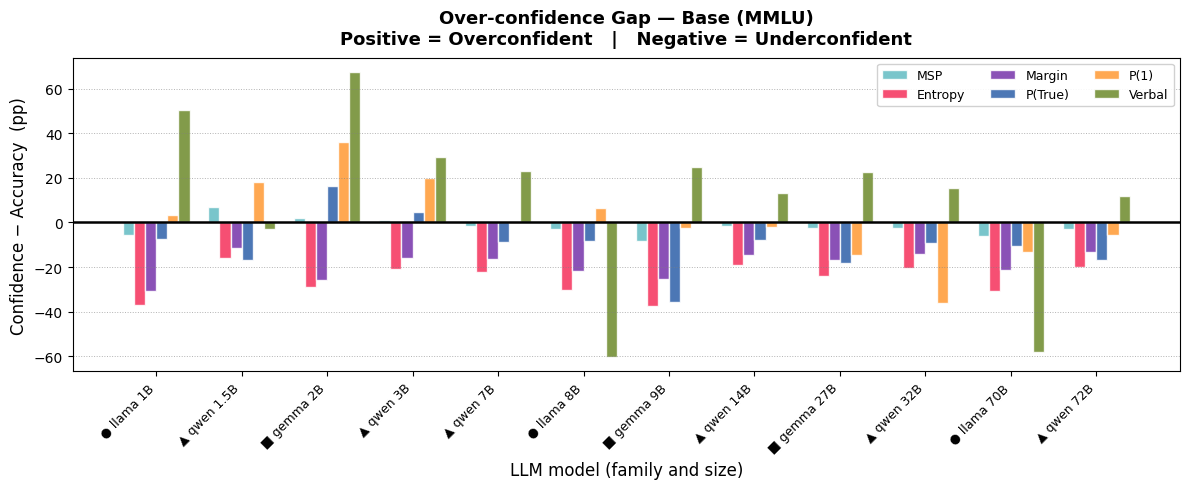

In [9]:
def plot_overconfidence(scores, title, save_as=None):
    """Grouped bars of (confidence - accuracy) per metric across models."""
    metrics = list(CONF_METRICS.keys())
    x = np.arange(len(scores))
    n = len(metrics)
    bw = 0.13
    offsets = np.linspace(-(n - 1) / 2 * bw, (n - 1) / 2 * bw, n)

    fig, ax = plt.subplots(figsize=(12, 5))
    acc = scores["accuracy"].values
    for i, key in enumerate(metrics):
        gaps = scores[key].values - acc
        ax.bar(x + offsets[i], gaps, bw, color=METRIC_COLORS[key],
               alpha=0.85, label=SHORT[key], edgecolor="white")

    ax.axhline(0, color="black", lw=1.8)
    ax.set_xticks(x)
    ax.set_xticklabels([f"{FAM_GLYPH.get(f, '')} {lab}"
                        for f, lab in zip(scores["family"], scores["label"])],
                       rotation=45, ha="right", fontsize=9)
    ax.set_xlabel("LLM model (family and size)", fontsize=12)
    ax.set_ylabel("Confidence \u2212 Accuracy  (pp)", fontsize=12)
    ax.set_title(title + "\nPositive = Overconfident   |   Negative = Underconfident",
                 fontsize=13, fontweight="bold", pad=10)
    ax.grid(axis="y", linestyle=":", linewidth=0.7, alpha=0.6, color="grey")
    ax.legend(loc="upper right", fontsize=9, framealpha=0.9, ncol=3)
    fig.tight_layout()
    if SAVE_FIGS and save_as:
        fig.savefig(save_as, dpi=FIG_DPI, bbox_inches="tight",
                    facecolor="white", edgecolor="none")
        print("saved", save_as)
    plt.show()
    return fig


plot_overconfidence(scores_instruct_mmlu, "Over-confidence Gap — Instruct (MMLU)",
                    save_as="figB_overconfidence_instruct_mmlu.png")
plot_overconfidence(scores_base_mmlu, "Over-confidence Gap — Base (MMLU)",
                    save_as="figB_overconfidence_base_mmlu.png");


## 8. Figure C — Reliability diagrams (calibration curves)

For each metric, confidence is split into 10 bins; we plot mean accuracy against mean confidence per bin, one line per model, with the **black dashed diagonal** marking perfect calibration. Lines **below** the diagonal = over-confident in that confidence range; **above** = under-confident. Watching the curves move toward the diagonal as models get larger is the per-bin view of the same calibration story.


saved figC_reliability_instruct_mmlu.png


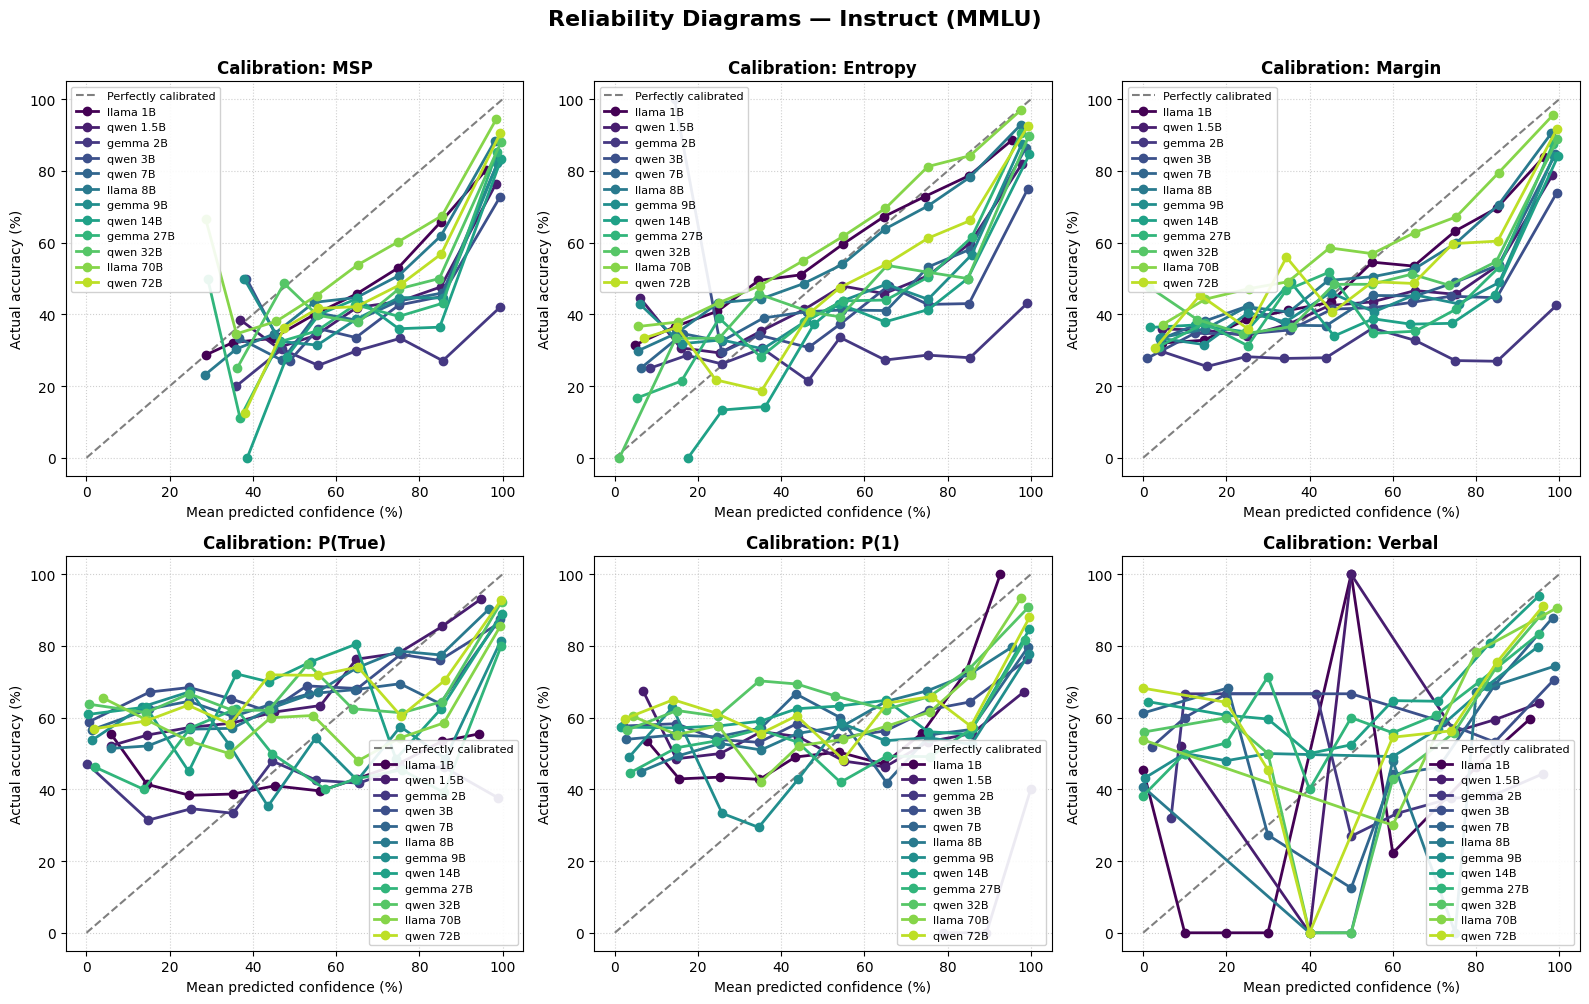

In [10]:
def plot_reliability(loaded, title, n_bins=10, save_as=None):
    """2x3 grid of calibration curves (one panel per metric, one line per model)."""
    metrics = list(CONF_METRICS.keys())
    model_labels = [f"{fam} {sz:g}B" for sz, fam, _, _ in loaded]
    colours = plt.cm.viridis(np.linspace(0, 0.9, max(len(loaded), 1)))

    fig, axes = plt.subplots(2, 3, figsize=(16, 10))
    axes = axes.flatten()

    for i, key in enumerate(metrics):
        ax = axes[i]
        cands, scale = CONF_METRICS[key]
        ax.plot([0, 100], [0, 100], color="black", linestyle="--",
                alpha=0.5, label="Perfectly calibrated", zorder=1)

        for j, (size, family, df, fn) in enumerate(loaded):
            col = first_present(df, cands)
            if col is None:
                continue
            sub = pd.DataFrame({
                "conf": pd.to_numeric(df[col], errors="coerce") * scale,
                "acc":  pd.to_numeric(df["is_correct"], errors="coerce") * 100,
            }).dropna().reset_index(drop=True)
            if sub.empty:
                continue

            bins = np.linspace(0, 100, n_bins + 1)
            idx = np.digitize(sub["conf"], bins) - 1
            idx = idx.clip(0, n_bins - 1)
            bin_conf, bin_acc = [], []
            for b in range(n_bins):
                mask = (idx == b)
                if mask.any():
                    bin_conf.append(sub["conf"][mask].mean())
                    bin_acc.append(sub["acc"][mask].mean())
            ax.plot(bin_conf, bin_acc, marker="o", linewidth=2, markersize=6,
                    color=colours[j], label=model_labels[j])

        ax.set_title(f"Calibration: {CONF_LABELS[key]}", fontsize=12, fontweight="bold", pad=6)
        ax.set_xlabel("Mean predicted confidence (%)", fontsize=10)
        ax.set_ylabel("Actual accuracy (%)", fontsize=10)
        ax.set_xlim(-5, 105)
        ax.set_ylim(-5, 105)
        ax.grid(True, linestyle=":", alpha=0.6)
        ax.legend(fontsize=8, framealpha=0.9)

    fig.suptitle(title, fontsize=16, fontweight="bold", y=1.0)
    fig.tight_layout()
    if SAVE_FIGS and save_as:
        fig.savefig(save_as, dpi=FIG_DPI, bbox_inches="tight",
                    facecolor="white", edgecolor="none")
        print("saved", save_as)
    plt.show()
    return fig


plot_reliability(loaded_instruct_mmlu, "Reliability Diagrams — Instruct (MMLU)",
                 save_as="figC_reliability_instruct_mmlu.png");


## 9. Figure D — Calibration-metric heatmaps

A compact summary of Section 5: four heatmaps (ECE, Brier, AUROC, Pearson *r*), rows = confidence metrics, columns = models (small→large). Colour runs green→good in each panel (ECE and Brier are reversed since lower is better). Scanning a row left→right shows how that metric's calibration/discrimination shifts with scale — the clearest place to see the **AUROC-improves-while-ECE-may-not** dissociation.


saved figD_heatmaps_instruct_mmlu.png


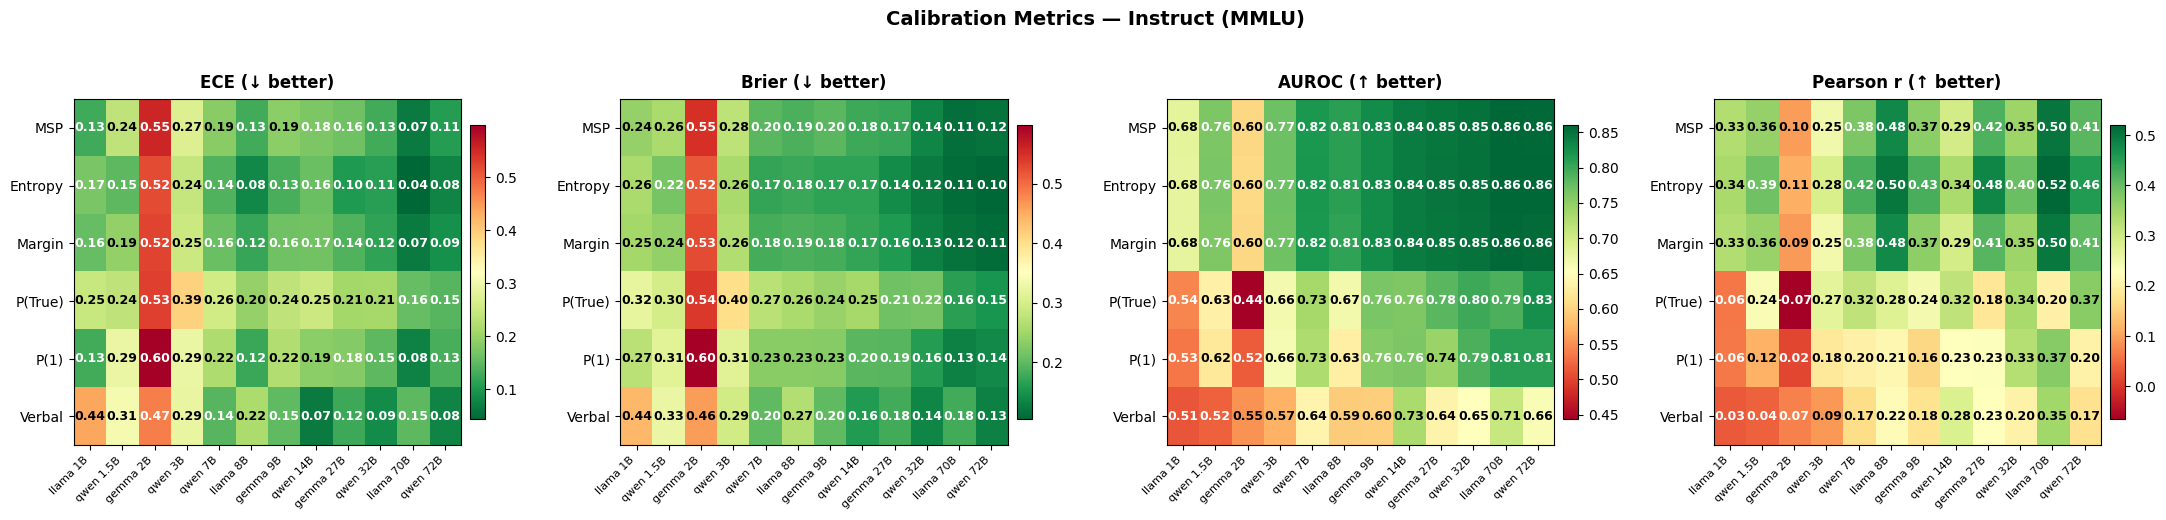

In [11]:
def plot_calibration_heatmaps(results, model_labels, title, save_as=None):
    """Four heatmaps (ECE, Brier, AUROC, Corr); rows = metrics, cols = models."""
    stat_keys   = ["ECE", "Brier", "AUROC", "Corr"]
    stat_titles = ["ECE (\u2193 better)", "Brier (\u2193 better)",
                   "AUROC (\u2191 better)", "Pearson r (\u2191 better)"]
    cmaps       = ["RdYlGn_r", "RdYlGn_r", "RdYlGn", "RdYlGn"]
    metrics     = list(CONF_METRICS.keys())
    row_labels  = [CONF_LABELS[k] for k in metrics]

    fig, axes = plt.subplots(1, 4, figsize=(22, 5))
    for ax, stat, t, cmap in zip(axes, stat_keys, stat_titles, cmaps):
        M = np.array([[results[k][lab][stat] for lab in model_labels] for k in metrics])
        vmin, vmax = np.nanmin(M), np.nanmax(M)
        im = ax.imshow(M, cmap=cmap, aspect="auto", vmin=vmin, vmax=vmax)

        for r in range(len(metrics)):
            for c in range(len(model_labels)):
                val = M[r, c]
                if np.isnan(val):
                    continue
                nv = (val - vmin) / (vmax - vmin + 1e-9)
                tc = "white" if (nv < 0.25 or nv > 0.75) else "black"
                ax.text(c, r, f"{val:.2f}", ha="center", va="center",
                        fontsize=9, fontweight="bold", color=tc)

        ax.set_xticks(range(len(model_labels)))
        ax.set_xticklabels(model_labels, rotation=45, ha="right", fontsize=8)
        ax.set_yticks(range(len(metrics)))
        ax.set_yticklabels(row_labels, fontsize=10)
        ax.set_title(t, fontsize=12, fontweight="bold", pad=8)
        plt.colorbar(im, ax=ax, shrink=0.85, pad=0.02)

    fig.suptitle(title, fontsize=14, fontweight="bold", y=1.03)
    fig.tight_layout()
    if SAVE_FIGS and save_as:
        fig.savefig(save_as, dpi=FIG_DPI, bbox_inches="tight",
                    facecolor="white", edgecolor="none")
        print("saved", save_as)
    plt.show()
    return fig


plot_calibration_heatmaps(cal_instruct_mmlu, labels_instruct_mmlu,
                          "Calibration Metrics — Instruct (MMLU)",
                          save_as="figD_heatmaps_instruct_mmlu.png");


## Notes

- **Reading the figures together.** A Dunning–Kruger pattern shows up as: confidence above accuracy for the weaker models (Fig A), a positive over-confidence gap that narrows with scale (Fig B), reliability curves drifting toward the diagonal (Fig C), and AUROC rising across columns even where ECE is flat (Fig D). Whether each holds — and in which condition/benchmark — is what the dissertation reports.
- **Base vs. Instruct.** The two-column figures put base and instruction-tuned models side by side, which is what isolates instruction tuning as a driver rather than scale alone.
- **Reproducing all conditions.** Each plotting cell above is shown for one condition to keep the notebook readable; call the same function with `scores_base_mmlu`, `scores_instruct_mmlupro`, `loaded_base_mmlupro`, `cal_base_pro`, etc. to produce the full set.
- **What was trimmed.** The original exploratory notebooks repeated several variants to allow careful analysis of the trend for each fmaily. This notebook combines all key functions used for ease of explaination. 